In [0]:
# Load user email
user = 'francisco.morales@koantek.com'

# Load dataset - Update path after uploading to Databricks
df = spark.read.option("header", True).option("inferSchema", True).csv(
    f"file:/Workspace/Users/{user}/DPP_Bootcamp/datasets/chocolate_bars/chocolate_bar_ratings.csv"
).toPandas()

# define target
target_col = 'rating'  # Update based on your dataset

In [0]:
df.head(15)

,id,manufacturer,company_location,year_reviewed,bean_origin,bar_name,cocoa_percent,num_ingredients,ingredients,rating,record_id_hash,source_system,user_id
0,2454.0,5150,U.S.A.,2019.0,None,"Kokoa Kamili, batch 1",76.0,3.0,"B,S,C",3.0,NOISE_145,4534,3517
1,2458.0,5150,U.S.A.,2019.0,Dominican Republic,"Zorzal, batch 1",76.0,3.0,None,None,NOISE_959,2998,1961
2,2454.0,5150,U.S.A.,2019.0,Madagascar,"Bejofo Estate, batch 1",76.0,3.0,"B,S,C",4.0,NOISE_789,5495,4933
3,2542.0,5150,U.S.A.,2021.0,Fiji,"Matasawalevu, batch 1",68.0,3.0,"B,S,C",3.0,NOISE_740,9026,3666
4,2546.0,5150,U.S.A.,2021.0,Venezuela,"Sur del Lago, batch 1",72.0,3.0,"B,S,C",3.0,NOISE_622,7884,7184
5,2546.0,5150,U.S.A.,2021.0,Uganda,"Semuliki Forest, batch 1",80.0,3.0,"B,S,C",3.0,NOISE_337,1803,1199
6,2542.0,5150,U.S.A.,2021.0,India,"Anamalai, batch 1",68.0,3.0,"B,S,C",4.0,NOISE_557,4599,8002
7,797.0,A. Morin,France,2012.0,Bolivia,Bolivia,70.0,4.0,"['B','S','C','L']",None,NOISE_750,7912,2245
8,797.0,A. Morin,France,2012.0,Peru,Peru,63.0,4,"B,S,C,L",4.0,NOISE_380,8012,5401
9,1011.0,A. Morin,FRANCE,2013.0,Panama,Panama,70.0,4.0,"B,S,C,L",3.0,NOISE_551,2829,2764


In [0]:
dbutils.data.summarize(df)

<!DOCTYPE html>

In [0]:
import pandas as pd
import re

# Convert year_reviewed to object (string) - round to nearest year first
df['year_reviewed'] = pd.to_numeric(df['year_reviewed'], errors='coerce').round(0).astype(int).astype(str)

# Convert cocoa_percent to numeric (extract numeric value, remove '%' and other text)
df['cocoa_percent'] = df['cocoa_percent'].apply(lambda x: float(re.findall(r'\d+\.?\d*', str(x))[0]) if pd.notna(x) and re.findall(r'\d+\.?\d*', str(x)) else None)

# Convert num_ingredients to numeric (extract numeric value) and round to nearest integer
df['num_ingredients'] = df['num_ingredients'].apply(lambda x: float(re.findall(r'\d+', str(x))[0]) if pd.notna(x) and re.findall(r'\d+', str(x)) else None)
df['num_ingredients'] = df['num_ingredients'].round(0)

# Verify the changes
print("Data types after correction:")
print(df[['year_reviewed', 'cocoa_percent', 'num_ingredients']].dtypes)
print("\nSample values:")
print(df[['year_reviewed', 'cocoa_percent', 'num_ingredients']].head(10))

Data types after correction:
year_reviewed       object
cocoa_percent      float64
num_ingredients    float64
dtype: object

Sample values:
  year_reviewed  cocoa_percent  num_ingredients
0          2019           76.0              3.0
1          2019           76.0              3.0
2          2019           76.0              3.0
3          2021           68.0              3.0
4          2021           72.0              3.0
5          2021           80.0              3.0
6          2021           68.0              3.0
7          2012           70.0              4.0
8          2012           63.0              4.0
9          2013           70.0              4.0


In [0]:
df.dtypes

id                  float64
manufacturer         object
company_location     object
year_reviewed        object
bean_origin          object
bar_name             object
cocoa_percent       float64
num_ingredients     float64
ingredients          object
rating               object
record_id_hash       object
source_system        object
user_id              object
dtype: object

In [0]:
# Check current rating values and distribution
print("Current Rating Column Data Type:", df['rating'].dtype)
print("\nUnique Rating Values:")
print(df['rating'].value_counts().sort_index())
print(f"\nRating Statistics:")
print(f"  Total values: {df['rating'].count()}")
print(f"  Missing values: {df['rating'].isnull().sum()}")
print(f"  Unique values: {df['rating'].nunique()}")

Current Rating Column Data Type: float64

Unique Rating Values:
0.0      24
1.0       5
2.0     223
3.0    1286
4.0     937
5.0      26
Name: rating, dtype: int64

Rating Statistics:
  Total values: 2501
  Missing values: 79
  Unique values: 6


In [0]:
# Convert rating to numeric (handle any non-numeric values)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Round to nearest whole number
df['rating'] = df['rating'].round(0)

# Cap outliers: values < 0 become 0, values > 5 become 5
df['rating'] = df['rating'].clip(lower=0, upper=5)

print("Rating values after cleaning:")
print(df['rating'].value_counts().sort_index())
print(f"\nCleaned Rating Statistics:")
print(f"  Min: {df['rating'].min()}")
print(f"  Max: {df['rating'].max()}")
print(f"  Mean: {df['rating'].mean():.2f}")
print(f"  Median: {df['rating'].median()}")
print(f"  Missing values: {df['rating'].isnull().sum()}")

Rating values after cleaning:
0.0      24
1.0       5
2.0     223
3.0    1286
4.0     937
5.0      26
Name: rating, dtype: int64

Cleaned Rating Statistics:
  Min: 0.0
  Max: 5.0
  Mean: 3.27
  Median: 3.0
  Missing values: 79


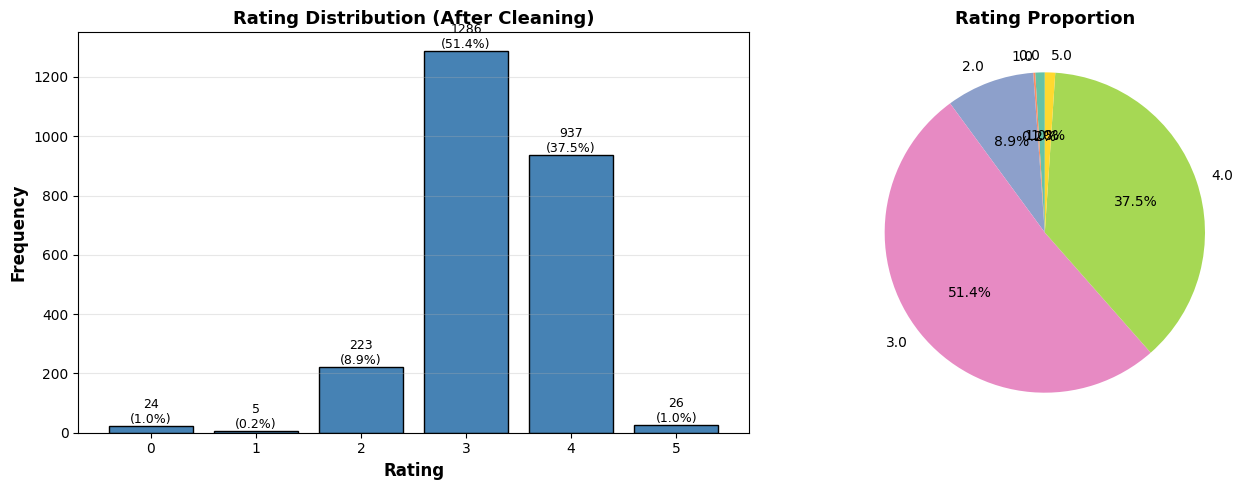


Class Balance Analysis:
  Rating 0: 24 samples (0.96%)
  Rating 1: 5 samples (0.20%)
  Rating 2: 223 samples (8.92%)
  Rating 3: 1286 samples (51.42%)
  Rating 4: 937 samples (37.47%)
  Rating 5: 26 samples (1.04%)


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of rating distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rating', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Rating Distribution (After Cleaning)', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1, 2, 3, 4, 5])
axes[0].grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for idx, val in rating_counts.items():
    pct = val / len(df[df['rating'].notna()]) * 100
    axes[0].text(idx, val, f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette('Set2', len(rating_counts)))
axes[1].set_title('Rating Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nClass Balance Analysis:")
for rating, count in rating_counts.items():
    pct = count / len(df[df['rating'].notna()]) * 100
    print(f"  Rating {int(rating)}: {count} samples ({pct:.2f}%)")

In [0]:
# Analyze missing values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])
print(f"\nTotal columns with missing values: {(missing_df['Missing_Count'] > 0).sum()}")

Missing Values Summary:
            Column  Missing_Count  Missing_Percent
8      ingredients            213         8.255814
4      bean_origin            209         8.100775
7  num_ingredients             89         3.449612
9           rating             79         3.062016
6    cocoa_percent              6         0.232558

Total columns with missing values: 5


In [0]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Select numeric columns for outlier detection
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns for outlier detection: {numeric_cols}")

# Prepare data (drop rows with missing values in numeric columns)
df_numeric = df[numeric_cols].dropna()

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(df_numeric)

# Count outliers
outlier_count = (outlier_labels == -1).sum()
print(f"\nTotal outliers detected: {outlier_count} ({outlier_count/len(df_numeric)*100:.2f}%)")

# Add outlier flag to original dataframe
df['is_outlier'] = False
df.loc[df_numeric.index, 'is_outlier'] = outlier_labels == -1

print(f"\nOutlier distribution by target (rating):")
print(df.groupby('is_outlier')['rating'].value_counts().sort_index())

Numeric columns for outlier detection: ['id', 'cocoa_percent', 'num_ingredients', 'rating']


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]


Total outliers detected: 121 (5.01%)

Outlier distribution by target (rating):
is_outlier  rating
False       0.0          1
            1.0          4
            2.0        185
            3.0       1256
            4.0        916
            5.0         18
True        0.0         23
            1.0          1
            2.0         38
            3.0         30
            4.0         21
            5.0          8
Name: rating, dtype: int64


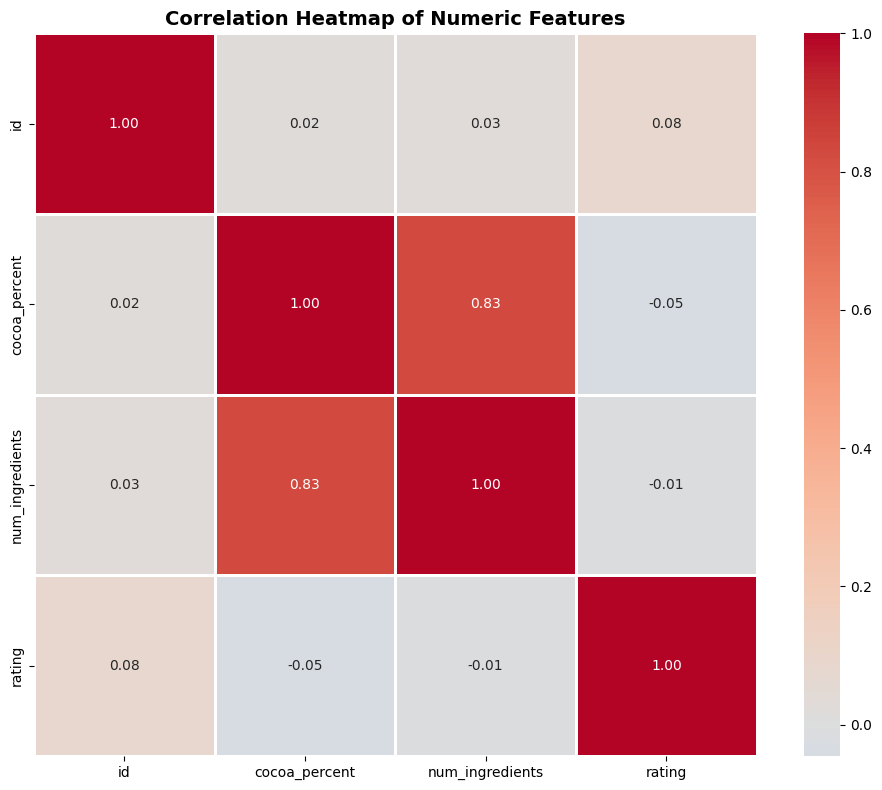


Correlations with target (rating):
rating             1.000000
id                 0.081823
num_ingredients   -0.008356
cocoa_percent     -0.045650
Name: rating, dtype: float64


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlations with target variable
if 'rating' in numeric_df.columns:
    target_corr = corr_matrix['rating'].sort_values(ascending=False)
    print("\nCorrelations with target (rating):")
    print(target_corr)

In [0]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns: {categorical_cols}\n")
print("="*80)

# Analyze cardinality and case sensitivity issues
for col in categorical_cols:
    unique_count = df[col].nunique()
    total_count = df[col].count()
    
    print(f"\n{col.upper()}:")
    print(f"  Unique values: {unique_count}")
    print(f"  Total non-null: {total_count}")
    print(f"  Cardinality: {unique_count/total_count*100:.2f}%")
    
    # Check for case sensitivity issues
    value_counts = df[col].value_counts()
    lower_value_counts = df[col].str.lower().value_counts()
    
    if len(value_counts) != len(lower_value_counts):
        print(f"  ⚠️ CASE SENSITIVITY ISSUE DETECTED!")
        print(f"  Original unique: {len(value_counts)}, Lowercase unique: {len(lower_value_counts)}")
        
        # Show examples of case variations
        case_issues = {}
        for val in df[col].dropna().unique():
            lower_val = str(val).lower()
            if lower_val not in case_issues:
                case_issues[lower_val] = []
            case_issues[lower_val].append(val)
        
        duplicates = {k: v for k, v in case_issues.items() if len(v) > 1}
        if duplicates:
            print(f"  Examples of case variations:")
            for lower_val, variations in list(duplicates.items())[:3]:
                print(f"    {variations}")
    
    # Show top values
    print(f"  Top 5 values:")
    for val, count in value_counts.head(5).items():
        print(f"    {val}: {count} ({count/total_count*100:.1f}%)")
    
    print("-"*80)

Categorical columns: ['manufacturer', 'company_location', 'year_reviewed', 'bean_origin', 'bar_name', 'ingredients', 'rating', 'record_id_hash', 'source_system', 'user_id']


MANUFACTURER:
  Unique values: 797
  Total non-null: 2580
  Cardinality: 30.89%
  Top 5 values:
    nan: 206 (8.0%)
    Soma: 49 (1.9%)
    Fresco: 28 (1.1%)
    Arete: 25 (1.0%)
    Bonnat: 21 (0.8%)
--------------------------------------------------------------------------------

COMPANY_LOCATION:
  Unique values: 121
  Total non-null: 2580
  Cardinality: 4.69%
  ⚠️ CASE SENSITIVITY ISSUE DETECTED!
  Original unique: 121, Lowercase unique: 69
  Examples of case variations:
    ['France', 'FRANCE', 'france']
    ['Vanuatu', 'VANUATU', 'vanuatu']
    ['Ecuador', 'ecuador', 'ECUADOR']
  Top 5 values:
    U.S.A.: 1029 (39.9%)
    France: 162 (6.3%)
    Canada: 155 (6.0%)
    U.K.: 124 (4.8%)
    United States: 76 (2.9%)
--------------------------------------------------------------------------------

YEAR_REVIEWED:


In [0]:
# Fix case sensitivity issues by converting to lowercase
print("Before standardization:")
print(f"  company_location unique values: {df['company_location'].nunique()}")
print(f"  bar_name unique values: {df['bar_name'].nunique()}")

# Convert to lowercase to standardize
df['company_location'] = df['company_location'].str.lower()
df['bar_name'] = df['bar_name'].str.lower()

print("\nAfter standardization:")
print(f"  company_location unique values: {df['company_location'].nunique()}")
print(f"  bar_name unique values: {df['bar_name'].nunique()}")

# Show top values after standardization
print("\nTop 10 company_location values after standardization:")
print(df['company_location'].value_counts().head(10))

print("\nTop 10 bar_name values after standardization:")
print(df['bar_name'].value_counts().head(10))

Before standardization:
  company_location unique values: 121
  bar_name unique values: 1707

After standardization:
  company_location unique values: 69
  bar_name unique values: 1705

Top 10 company_location values after standardization:
u.s.a.           1029
canada            181
france            180
u.k.              136
italy              79
united states      76
belgium            64
ecuador            59
australia          55
usa                53
Name: company_location, dtype: int64

Top 10 bar_name values after standardization:
madagascar            44
dominican republic    31
peru                  31
ecuador               31
chuao                 22
kokoa kamili          18
venezuela             17
ghana                 16
ucayali               16
ocumare               15
Name: bar_name, dtype: int64


In [0]:
# Create mapping for country name variations
country_mapping = {
    'u.s.a.': 'usa',
    'united states': 'usa',
    'u.k.': 'uk',
    'united kingdom': 'uk',
    'scotland': 'uk',
    'wales': 'uk',
    'amsterdam': 'netherlands',
    'sao tome': 'sao tome and principe',
    'st. lucia': 'saint lucia',
    'south korea': 'korea',
    'nz': 'new zealand'
}

print("Before consolidation:")
print(f"  Unique company_location values: {df['company_location'].nunique()}")
print(f"\nTop 15 values before:")
print(df['company_location'].value_counts().head(15))

# Apply mapping
df['company_location'] = df['company_location'].replace(country_mapping)

print("\n" + "="*80)
print("\nAfter consolidation:")
print(f"  Unique company_location values: {df['company_location'].nunique()}")
print(f"\nTop 15 values after:")
print(df['company_location'].value_counts().head(15))

# Show reduction
print(f"\nReduction: {121 - df['company_location'].nunique()} unique values consolidated")

Before consolidation:
  Unique company_location values: 69

Top 15 values before:
u.s.a.           1029
canada            181
france            180
u.k.              136
italy              79
united states      76
belgium            64
ecuador            59
australia          55
usa                53
switzerland        45
germany            44
spain              36
denmark            33
japan              32
Name: company_location, dtype: int64


After consolidation:
  Unique company_location values: 64

Top 15 values after:
usa            1158
canada          181
france          180
uk              148
italy            79
belgium          64
ecuador          59
australia        55
switzerland      45
germany          44
spain            36
denmark          33
japan            32
venezuela        31
austria          30
Name: company_location, dtype: int64

Reduction: 57 unique values consolidated


In [0]:
# Analyze outlier characteristics
print("Outlier Summary:")
print(f"Total outliers: {df['is_outlier'].sum()} ({df['is_outlier'].sum()/len(df)*100:.2f}%)")
print(f"Normal samples: {(~df['is_outlier']).sum()} ({(~df['is_outlier']).sum()/len(df)*100:.2f}%)")

# Compare numeric features between outliers and normal samples
print("\n" + "="*80)
print("\nNumeric Feature Comparison (Outliers vs Normal):")
print("="*80)

numeric_features = ['cocoa_percent', 'num_ingredients', 'rating']

for feature in numeric_features:
    outlier_vals = df[df['is_outlier']][feature].dropna()
    normal_vals = df[~df['is_outlier']][feature].dropna()
    
    print(f"\n{feature.upper()}:")
    print(f"  Outliers - Mean: {outlier_vals.mean():.2f}, Median: {outlier_vals.median():.2f}, Std: {outlier_vals.std():.2f}")
    print(f"  Normal   - Mean: {normal_vals.mean():.2f}, Median: {normal_vals.median():.2f}, Std: {normal_vals.std():.2f}")
    print(f"  Difference in means: {abs(outlier_vals.mean() - normal_vals.mean()):.2f}")

Outlier Summary:
Total outliers: 121 (4.69%)
Normal samples: 2459 (95.31%)


Numeric Feature Comparison (Outliers vs Normal):

COCOA_PERCENT:
  Outliers - Mean: 75.68, Median: 71.00, Std: 53.89
  Normal   - Mean: 76.73, Median: 70.00, Std: 244.66
  Difference in means: 1.05

NUM_INGREDIENTS:
  Outliers - Mean: 3.49, Median: 3.00, Std: 1.30
  Normal   - Mean: 28.63, Median: 3.00, Std: 1239.01
  Difference in means: 25.14

RATING:
  Outliers - Mean: 2.40, Median: 2.00, Std: 1.47
  Normal   - Mean: 3.32, Median: 3.00, Std: 0.63
  Difference in means: 0.91


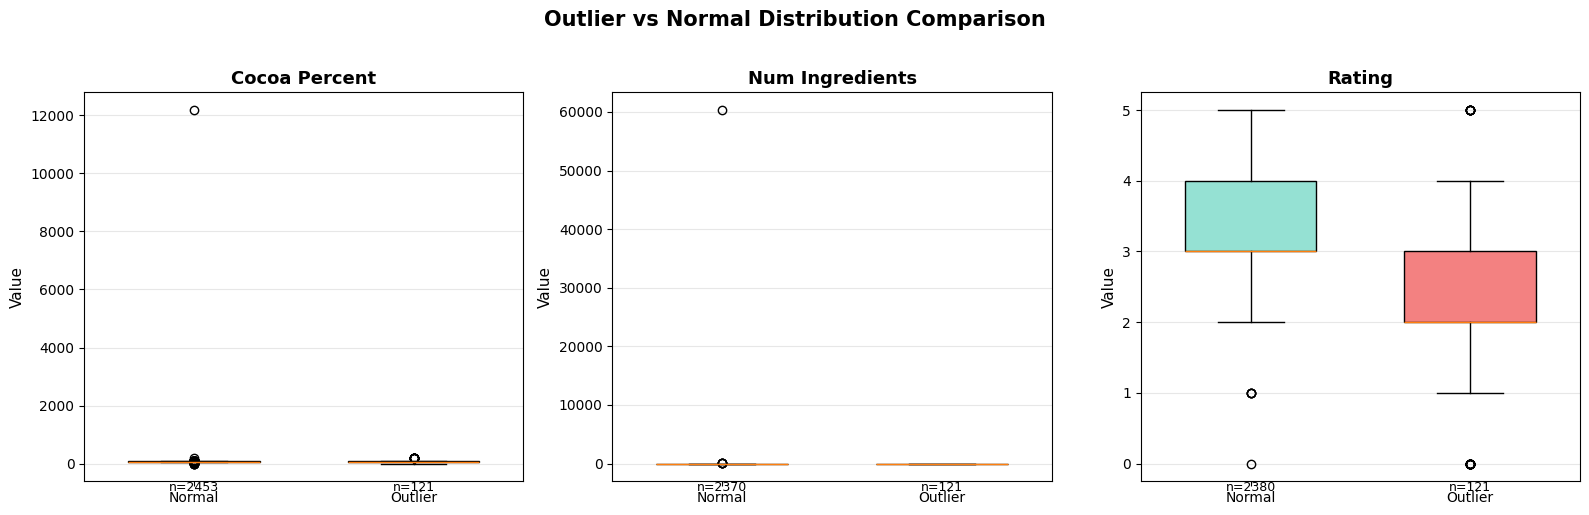

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots for numeric features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

numeric_features = ['cocoa_percent', 'num_ingredients', 'rating']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, feature in enumerate(numeric_features):
    # Prepare data
    data_to_plot = [
        df[~df['is_outlier']][feature].dropna(),
        df[df['is_outlier']][feature].dropna()
    ]
    
    # Create box plot
    bp = axes[idx].boxplot(data_to_plot, labels=['Normal', 'Outlier'], 
                            patch_artist=True, widths=0.6)
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('#95E1D3')
    bp['boxes'][1].set_facecolor('#F38181')
    
    axes[idx].set_title(f'{feature.replace("_", " ").title()}', 
                        fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add count annotations
    normal_count = len(data_to_plot[0])
    outlier_count = len(data_to_plot[1])
    axes[idx].text(1, axes[idx].get_ylim()[0], f'n={normal_count}', 
                   ha='center', va='top', fontsize=9)
    axes[idx].text(2, axes[idx].get_ylim()[0], f'n={outlier_count}', 
                   ha='center', va='top', fontsize=9)

plt.suptitle('Outlier vs Normal Distribution Comparison', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

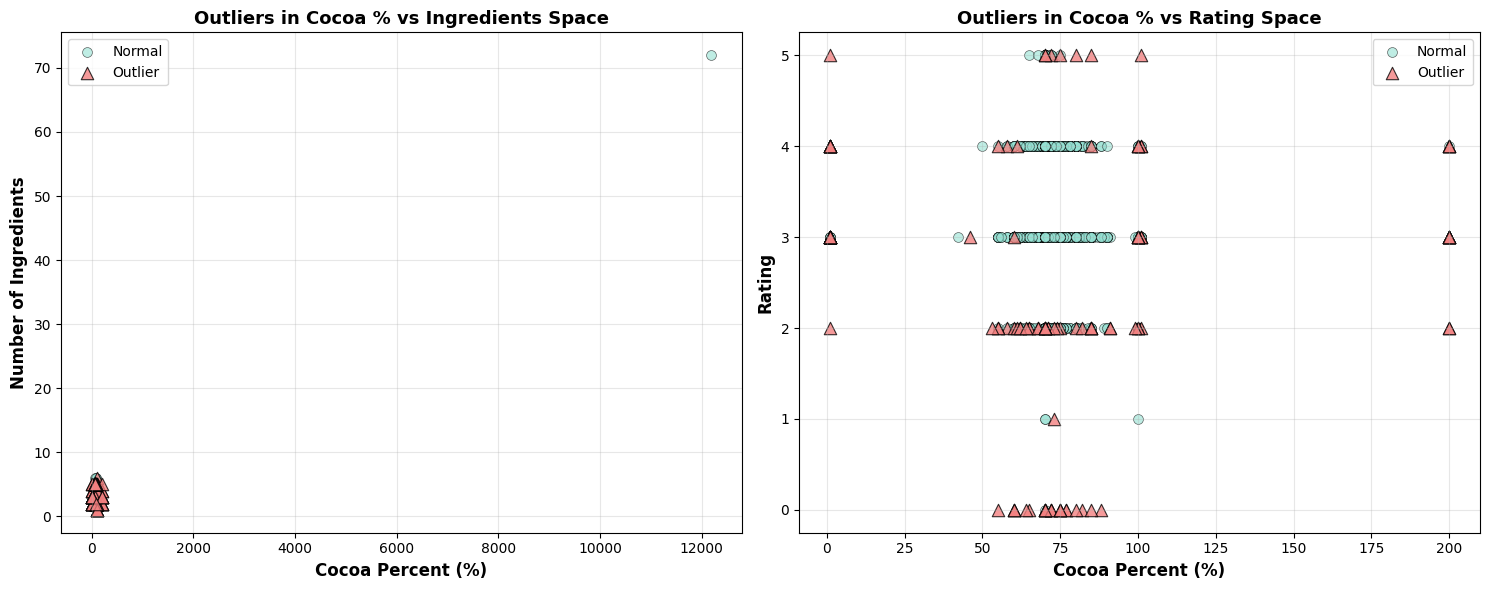

In [0]:
# Create scatter plots to visualize outliers in feature space
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot 1: cocoa_percent vs num_ingredients
axes[0].scatter(df[~df['is_outlier']]['cocoa_percent'], 
                df[~df['is_outlier']]['num_ingredients'],
                c='#95E1D3', alpha=0.6, s=50, label='Normal', edgecolors='black', linewidth=0.5)
axes[0].scatter(df[df['is_outlier']]['cocoa_percent'], 
                df[df['is_outlier']]['num_ingredients'],
                c='#F38181', alpha=0.8, s=80, label='Outlier', edgecolors='black', linewidth=0.8, marker='^')
axes[0].set_xlabel('Cocoa Percent (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Ingredients', fontsize=12, fontweight='bold')
axes[0].set_title('Outliers in Cocoa % vs Ingredients Space', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(alpha=0.3)

# Scatter plot 2: cocoa_percent vs rating
axes[1].scatter(df[~df['is_outlier']]['cocoa_percent'], 
                df[~df['is_outlier']]['rating'],
                c='#95E1D3', alpha=0.6, s=50, label='Normal', edgecolors='black', linewidth=0.5)
axes[1].scatter(df[df['is_outlier']]['cocoa_percent'], 
                df[df['is_outlier']]['rating'],
                c='#F38181', alpha=0.8, s=80, label='Outlier', edgecolors='black', linewidth=0.8, marker='^')
axes[1].set_xlabel('Cocoa Percent (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rating', fontsize=12, fontweight='bold')
axes[1].set_title('Outliers in Cocoa % vs Rating Space', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

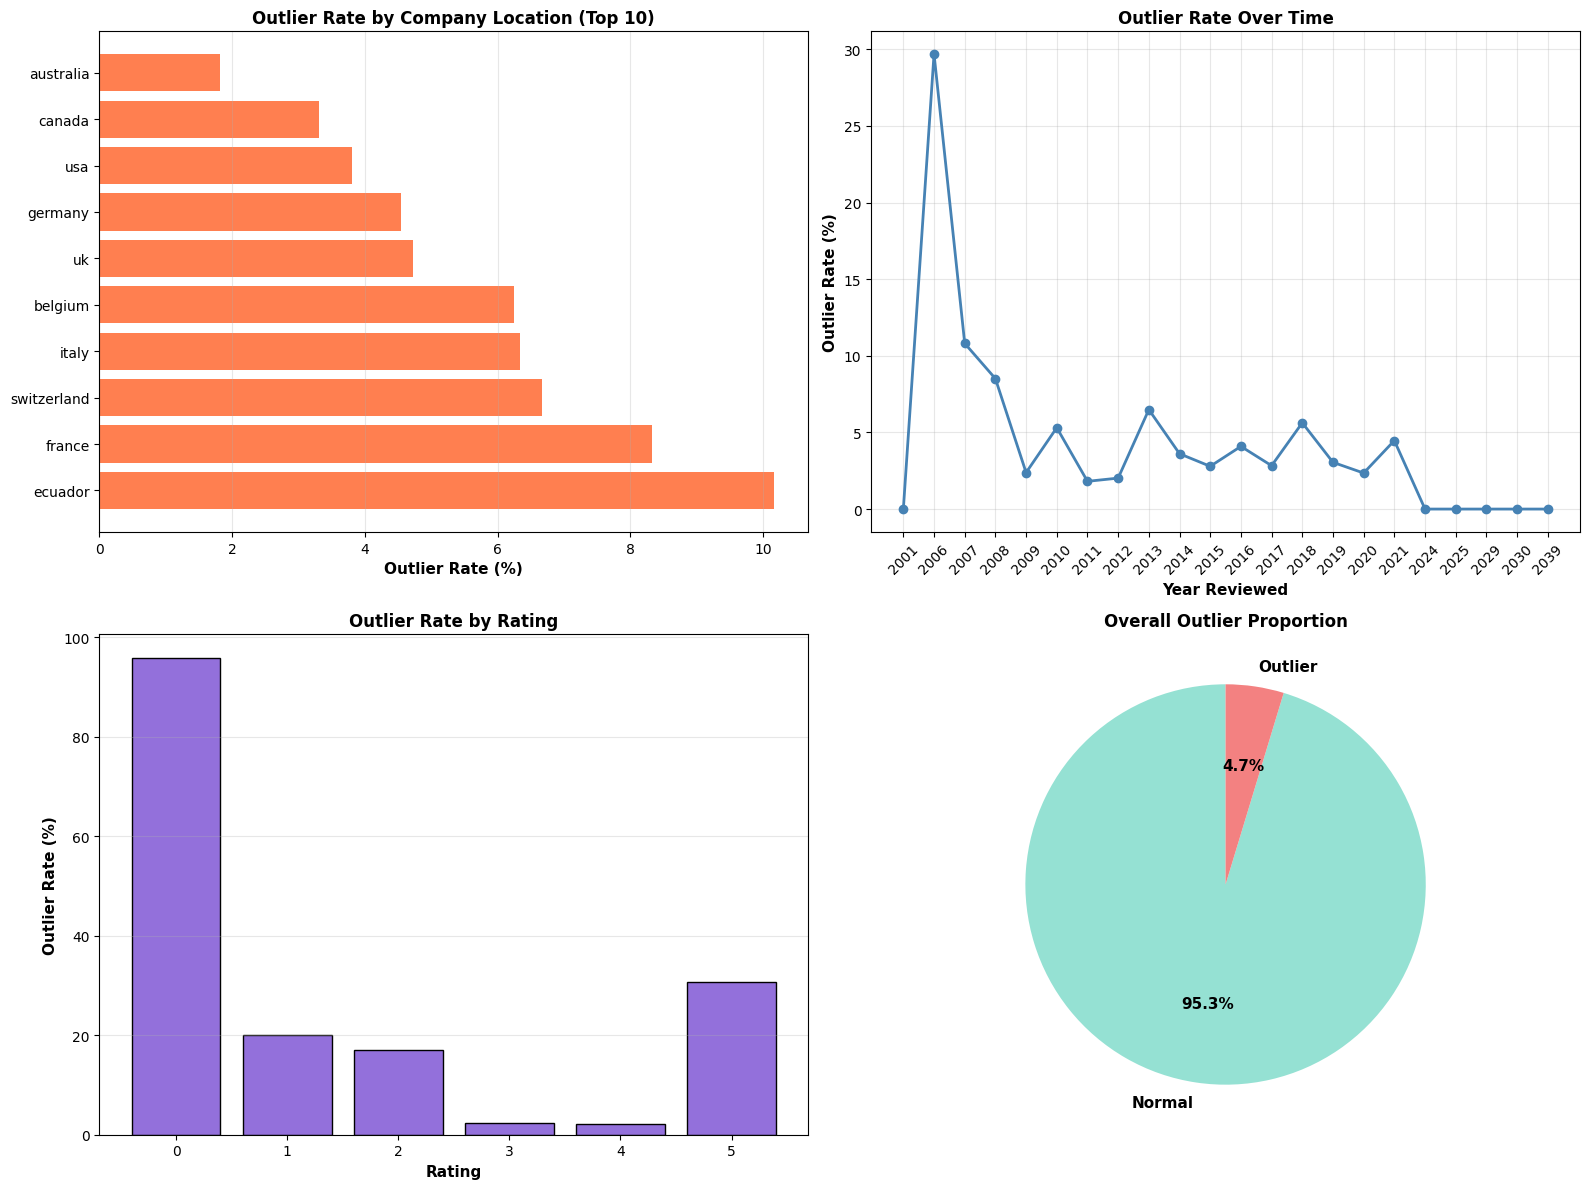


Key Insights:
  Highest outlier rate location: ecuador (10.17%)
  Lowest outlier rate location: australia (1.82%)


In [0]:
# Analyze outlier distribution across categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top company locations with outliers
top_locations = df['company_location'].value_counts().head(10).index
location_outliers = df[df['company_location'].isin(top_locations)].groupby('company_location')['is_outlier'].agg(['sum', 'count'])
location_outliers['outlier_rate'] = (location_outliers['sum'] / location_outliers['count'] * 100).round(2)
location_outliers = location_outliers.sort_values('outlier_rate', ascending=False)

axes[0, 0].barh(range(len(location_outliers)), location_outliers['outlier_rate'], color='coral')
axes[0, 0].set_yticks(range(len(location_outliers)))
axes[0, 0].set_yticklabels(location_outliers.index)
axes[0, 0].set_xlabel('Outlier Rate (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Outlier Rate by Company Location (Top 10)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Outliers by year
year_outliers = df.groupby('year_reviewed')['is_outlier'].agg(['sum', 'count'])
year_outliers['outlier_rate'] = (year_outliers['sum'] / year_outliers['count'] * 100).round(2)
year_outliers = year_outliers.sort_index()

axes[0, 1].plot(year_outliers.index, year_outliers['outlier_rate'], marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0, 1].set_xlabel('Year Reviewed', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Outlier Rate (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Outlier Rate Over Time', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Outliers by rating
rating_outliers = df.groupby('rating')['is_outlier'].agg(['sum', 'count'])
rating_outliers['outlier_rate'] = (rating_outliers['sum'] / rating_outliers['count'] * 100).round(2)

axes[1, 0].bar(rating_outliers.index, rating_outliers['outlier_rate'], color='mediumpurple', edgecolor='black')
axes[1, 0].set_xlabel('Rating', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Outlier Rate (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Outlier Rate by Rating', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks([0, 1, 2, 3, 4, 5])
axes[1, 0].grid(axis='y', alpha=0.3)

# Overall outlier proportion pie chart
outlier_counts = df['is_outlier'].value_counts()
axes[1, 1].pie(outlier_counts.values, labels=['Normal', 'Outlier'], autopct='%1.1f%%',
               colors=['#95E1D3', '#F38181'], startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1, 1].set_title('Overall Outlier Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"  Highest outlier rate location: {location_outliers.index[0]} ({location_outliers['outlier_rate'].iloc[0]:.2f}%)")
print(f"  Lowest outlier rate location: {location_outliers.index[-1]} ({location_outliers['outlier_rate'].iloc[-1]:.2f}%)")

In [0]:
# Show dataset size before removal
print("Before removing outliers:")
print(f"  Total rows: {len(df)}")
print(f"  Outliers: {df['is_outlier'].sum()}")
print(f"  Normal samples: {(~df['is_outlier']).sum()}")

# Remove outliers
df_clean = df[~df['is_outlier']].copy()

# Drop the is_outlier column as it's no longer needed
df_clean = df_clean.drop(columns=['is_outlier'])

print("\n" + "="*80)
print("\nAfter removing outliers:")
print(f"  Total rows: {len(df_clean)}")
print(f"  Rows removed: {len(df) - len(df_clean)}")
print(f"  Percentage removed: {(len(df) - len(df_clean))/len(df)*100:.2f}%")

# Update the main dataframe
df = df_clean

print("\nDataset shape after cleaning:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")

print("\nRemaining columns:")
print(df.columns.tolist())

Before removing outliers:
  Total rows: 2580
  Outliers: 121
  Normal samples: 2459


After removing outliers:
  Total rows: 2459
  Rows removed: 121
  Percentage removed: 4.69%

Dataset shape after cleaning:
  Rows: 2459
  Columns: 13

Remaining columns:
['id', 'manufacturer', 'company_location', 'year_reviewed', 'bean_origin', 'bar_name', 'cocoa_percent', 'num_ingredients', 'ingredients', 'rating', 'record_id_hash', 'source_system', 'user_id']


In [0]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Define columns to exclude from modeling
exclude_cols = ['id', 'record_id_hash', 'source_system', 'user_id', 'rating']

# Identify numeric and categorical features
numeric_features = ['cocoa_percent', 'num_ingredients']
categorical_features = ['manufacturer', 'company_location', 'year_reviewed', 
                        'bean_origin', 'bar_name', 'ingredients']

print("Feature Configuration:")
print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nExcluded columns ({len(exclude_cols)}): {exclude_cols}")
print(f"\nTarget variable: rating")

Feature Configuration:

Numeric features (2): ['cocoa_percent', 'num_ingredients']

Categorical features (6): ['manufacturer', 'company_location', 'year_reviewed', 'bean_origin', 'bar_name', 'ingredients']

Excluded columns (5): ['id', 'record_id_hash', 'source_system', 'user_id', 'rating']

Target variable: rating


In [0]:
# Numeric preprocessing pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'  # Drop any columns not specified
)

print("Preprocessing Pipeline Created Successfully!")
print("\nPipeline Structure:")
print("="*80)
print("\n1. NUMERIC PIPELINE (cocoa_percent, num_ingredients):")
print("   - Step 1: SimpleImputer(strategy='median')")
print("   - Step 2: StandardScaler()")
print("\n2. CATEGORICAL PIPELINE (manufacturer, company_location, year_reviewed, bean_origin, bar_name, ingredients):")
print("   - Step 1: SimpleImputer(strategy='constant', fill_value='unknown')")
print("   - Step 2: OneHotEncoder(handle_unknown='ignore', sparse_output=False)")
print("\n3. REMAINDER: drop (excludes id, record_id_hash, source_system, user_id)")
print("="*80)

Preprocessing Pipeline Created Successfully!

Pipeline Structure:

1. NUMERIC PIPELINE (cocoa_percent, num_ingredients):
   - Step 1: SimpleImputer(strategy='median')
   - Step 2: StandardScaler()

2. CATEGORICAL PIPELINE (manufacturer, company_location, year_reviewed, bean_origin, bar_name, ingredients):
   - Step 1: SimpleImputer(strategy='constant', fill_value='unknown')
   - Step 2: OneHotEncoder(handle_unknown='ignore', sparse_output=False)

3. REMAINDER: drop (excludes id, record_id_hash, source_system, user_id)


In [0]:
# Separate features and target
X = df.drop(columns=exclude_cols)
y = df['rating']

# Remove rows with missing target values
mask = y.notna()
X = X[mask]
y = y[mask]

print("Data Preparation Summary:")
print("="*80)
print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index())
print(f"\nMissing values in features:")
print(X.isnull().sum()[X.isnull().sum() > 0])
print("\nData is ready for train-test split and modeling!")

Data Preparation Summary:

Feature matrix (X) shape: (2380, 8)
Target vector (y) shape: (2380,)

Target distribution:
0.0       1
1.0       4
2.0     185
3.0    1256
4.0     916
5.0      18
Name: rating, dtype: int64

Missing values in features:
bean_origin        191
cocoa_percent        2
num_ingredients     87
ingredients        200
dtype: int64

Data is ready for train-test split and modeling!


In [0]:
%pip install xgboost==2.0.3 lightgbm==4.3.0 scikit-learn==1.4.0 mlflow==2.10.2 --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

# Define Quadratic Weighted Kappa metric
def quadratic_weighted_kappa(y_true, y_pred, min_rating=0, max_rating=5):
    """
    Calculate Quadratic Weighted Kappa for ordinal classification.
    """
    # Round predictions to nearest integer
    y_pred_rounded = np.round(y_pred).astype(int)
    y_pred_rounded = np.clip(y_pred_rounded, min_rating, max_rating)
    
    # Create confusion matrix
    num_ratings = max_rating - min_rating + 1
    conf_mat = np.zeros((num_ratings, num_ratings))
    
    for i in range(len(y_true)):
        conf_mat[int(y_true.iloc[i]) - min_rating, y_pred_rounded[i] - min_rating] += 1
    
    # Calculate weights matrix
    weights = np.zeros((num_ratings, num_ratings))
    for i in range(num_ratings):
        for j in range(num_ratings):
            weights[i, j] = ((i - j) ** 2) / ((num_ratings - 1) ** 2)
    
    # Calculate expected and observed matrices
    hist_true = np.sum(conf_mat, axis=1)
    hist_pred = np.sum(conf_mat, axis=0)
    expected = np.outer(hist_true, hist_pred) / np.sum(conf_mat)
    
    # Calculate kappa
    numerator = np.sum(weights * conf_mat)
    denominator = np.sum(weights * expected)
    
    if denominator == 0:
        return 0.0
    
    kappa = 1 - (numerator / denominator)
    return kappa

print("Libraries imported successfully!")
print("Quadratic Weighted Kappa metric defined.")

Libraries imported successfully!
Quadratic Weighted Kappa metric defined.


In [0]:
# Identify severely underrepresented classes (< 1% of data)
class_distribution = y.value_counts(normalize=True) * 100
print("Class distribution (%):\n", class_distribution.sort_index())

# Define threshold for underrepresented classes
underrepresented_threshold = 1.0  # 1%
underrepresented_classes = class_distribution[class_distribution < underrepresented_threshold].index.tolist()

print(f"\nUnderrepresented classes (< {underrepresented_threshold}%): {underrepresented_classes}")

# Separate underrepresented samples
mask_underrepresented = y.isin(underrepresented_classes)
X_underrepresented = X[mask_underrepresented]
y_underrepresented = y[mask_underrepresented]

# Keep well-represented samples for stratified split
X_main = X[~mask_underrepresented]
y_main = y[~mask_underrepresented]

print(f"\nMain dataset size: {len(X_main)}")
print(f"Underrepresented dataset size: {len(X_underrepresented)}")

# Perform stratified train/val/test split on main dataset
# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_main, y_main, test_size=0.30, random_state=42, stratify=y_main
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Add underrepresented samples back to training set
X_train = pd.concat([X_train, X_underrepresented], axis=0)
y_train = pd.concat([y_train, y_underrepresented], axis=0)

# Shuffle training set
shuffle_idx = np.random.RandomState(42).permutation(len(X_train))
X_train = X_train.iloc[shuffle_idx].reset_index(drop=True)
y_train = y_train.iloc[shuffle_idx].reset_index(drop=True)

print("\n" + "="*80)
print("\nData Split Summary:")
print(f"  Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print("\nValidation set class distribution:")
print(y_val.value_counts().sort_index())
print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())

Class distribution (%):
 0.0     0.042017
1.0     0.168067
2.0     7.773109
3.0    52.773109
4.0    38.487395
5.0     0.756303
Name: rating, dtype: float64

Underrepresented classes (< 1.0%): [5.0, 1.0, 0.0]

Main dataset size: 2357
Underrepresented dataset size: 23


Data Split Summary:
  Training set: 1672 samples (70.3%)
  Validation set: 354 samples (14.9%)
  Test set: 354 samples (14.9%)

Training set class distribution:
0.0      1
1.0      4
2.0    129
3.0    879
4.0    641
5.0     18
Name: rating, dtype: int64

Validation set class distribution:
2.0     28
3.0    188
4.0    138
Name: rating, dtype: int64

Test set class distribution:
2.0     28
3.0    189
4.0    137
Name: rating, dtype: int64


In [0]:
# Start MLflow experiment
mlflow.set_experiment("/Users/francisco.morales@koantek.com/chocolate_rating_ordinal_classification")

print("Training XGBoost Regressor...")
print("="*80)

with mlflow.start_run(run_name="XGBoost_Regressor") as run:
    # Calculate sample weights to handle class imbalance
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # Define XGBoost model with parameters for ordinal regression
    xgb_model = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    
    # Create full pipeline
    xgb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', xgb_model)
    ])
    
    # Train model
    xgb_pipeline.fit(X_train, y_train, regressor__sample_weight=sample_weights)
    
    # Make predictions
    y_train_pred = xgb_pipeline.predict(X_train)
    y_val_pred = xgb_pipeline.predict(X_val)
    y_test_pred = xgb_pipeline.predict(X_test)
    
    # Clip predictions to valid range [0, 5]
    y_train_pred = np.clip(y_train_pred, 0, 5)
    y_val_pred = np.clip(y_val_pred, 0, 5)
    y_test_pred = np.clip(y_test_pred, 0, 5)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_qwk = quadratic_weighted_kappa(y_train, y_train_pred)
    val_qwk = quadratic_weighted_kappa(y_val, y_val_pred)
    test_qwk = quadratic_weighted_kappa(y_test, y_test_pred)
    
    # Log parameters
    mlflow.log_param("model_type", "XGBoost Regressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("use_sample_weights", True)
    
    # Log metrics
    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("train_qwk", train_qwk)
    mlflow.log_metric("val_qwk", val_qwk)
    mlflow.log_metric("test_qwk", test_qwk)
    
    # Log model
    mlflow.sklearn.log_model(xgb_pipeline, "model")
    
    print(f"\nXGBoost Results:")
    print(f"  Train MAE: {train_mae:.4f} | Train QWK: {train_qwk:.4f}")
    print(f"  Val MAE:   {val_mae:.4f} | Val QWK:   {val_qwk:.4f}")
    print(f"  Test MAE:  {test_mae:.4f} | Test QWK:  {test_qwk:.4f}")
    print(f"\nMLflow Run ID: {run.info.run_id}")

2026/01/14 20:11:23 INFO mlflow.tracking.fluent: Experiment with name '/Users/francisco.morales@koantek.com/chocolate_rating_ordinal_classification' does not exist. Creating a new experiment.


Training XGBoost Regressor...


2026/01/14 20:11:28 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/repl_tmp_data/ReplId-19bbd-f284c-4/tmpwnx2dbv8/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.4.0', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2026/01/14 20:11:28 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.10.2, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/01/14 20:11:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]


XGBoost Results:
  Train MAE: 0.4258 | Train QWK: 0.5373
  Val MAE:   0.5582 | Val QWK:   0.2058
  Test MAE:  0.5246 | Test QWK:  0.2062

MLflow Run ID: c5ae72f3ed7a465abe60d11076d0dfd6


In [0]:
print("\nTraining Random Forest Regressor...")
print("="*80)

with mlflow.start_run(run_name="RandomForest_Regressor") as run:
    # Calculate sample weights to handle class imbalance
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # Define Random Forest model
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    
    # Create full pipeline
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', rf_model)
    ])
    
    # Train model
    rf_pipeline.fit(X_train, y_train, regressor__sample_weight=sample_weights)
    
    # Make predictions
    y_train_pred = rf_pipeline.predict(X_train)
    y_val_pred = rf_pipeline.predict(X_val)
    y_test_pred = rf_pipeline.predict(X_test)
    
    # Clip predictions to valid range [0, 5]
    y_train_pred = np.clip(y_train_pred, 0, 5)
    y_val_pred = np.clip(y_val_pred, 0, 5)
    y_test_pred = np.clip(y_test_pred, 0, 5)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_qwk = quadratic_weighted_kappa(y_train, y_train_pred)
    val_qwk = quadratic_weighted_kappa(y_val, y_val_pred)
    test_qwk = quadratic_weighted_kappa(y_test, y_test_pred)
    
    # Log parameters
    mlflow.log_param("model_type", "Random Forest Regressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 15)
    mlflow.log_param("min_samples_split", 10)
    mlflow.log_param("min_samples_leaf", 4)
    mlflow.log_param("use_sample_weights", True)
    
    # Log metrics
    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("train_qwk", train_qwk)
    mlflow.log_metric("val_qwk", val_qwk)
    mlflow.log_metric("test_qwk", test_qwk)
    
    # Log model
    mlflow.sklearn.log_model(rf_pipeline, "model")
    
    print(f"\nRandom Forest Results:")
    print(f"  Train MAE: {train_mae:.4f} | Train QWK: {train_qwk:.4f}")
    print(f"  Val MAE:   {val_mae:.4f} | Val QWK:   {val_qwk:.4f}")
    print(f"  Test MAE:  {test_mae:.4f} | Test QWK:  {test_qwk:.4f}")
    print(f"\nMLflow Run ID: {run.info.run_id}")


Training Random Forest Regressor...


2026/01/14 20:11:46 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/repl_tmp_data/ReplId-19bbd-f284c-4/tmpifuj19l6/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.4.0', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2026/01/14 20:11:46 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.10.2, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/01/14 20:11:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]


Random Forest Results:
  Train MAE: 0.5454 | Train QWK: 0.0543
  Val MAE:   0.5408 | Val QWK:   0.0642
  Test MAE:  0.5274 | Test QWK:  0.0531

MLflow Run ID: bf2f7051d18c4fc7ac678ae84054d0e8


In [0]:
print("\nTraining LightGBM Regressor...")
print("="*80)

with mlflow.start_run(run_name="LightGBM_Regressor") as run:
    # Calculate sample weights to handle class imbalance
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # Define LightGBM model
    lgbm_model = LGBMRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    # Create full pipeline
    lgbm_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', lgbm_model)
    ])
    
    # Train model
    lgbm_pipeline.fit(X_train, y_train, regressor__sample_weight=sample_weights)
    
    # Make predictions
    y_train_pred = lgbm_pipeline.predict(X_train)
    y_val_pred = lgbm_pipeline.predict(X_val)
    y_test_pred = lgbm_pipeline.predict(X_test)
    
    # Clip predictions to valid range [0, 5]
    y_train_pred = np.clip(y_train_pred, 0, 5)
    y_val_pred = np.clip(y_val_pred, 0, 5)
    y_test_pred = np.clip(y_test_pred, 0, 5)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_qwk = quadratic_weighted_kappa(y_train, y_train_pred)
    val_qwk = quadratic_weighted_kappa(y_val, y_val_pred)
    test_qwk = quadratic_weighted_kappa(y_test, y_test_pred)
    
    # Log parameters
    mlflow.log_param("model_type", "LightGBM Regressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 8)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("num_leaves", 31)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("use_sample_weights", True)
    
    # Log metrics
    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("train_qwk", train_qwk)
    mlflow.log_metric("val_qwk", val_qwk)
    mlflow.log_metric("test_qwk", test_qwk)
    
    # Log model
    mlflow.sklearn.log_model(lgbm_pipeline, "model")
    
    print(f"\nLightGBM Results:")
    print(f"  Train MAE: {train_mae:.4f} | Train QWK: {train_qwk:.4f}")
    print(f"  Val MAE:   {val_mae:.4f} | Val QWK:   {val_qwk:.4f}")
    print(f"  Test MAE:  {test_mae:.4f} | Test QWK:  {test_qwk:.4f}")
    print(f"\nMLflow Run ID: {run.info.run_id}")


Training LightGBM Regressor...


2026/01/14 20:12:07 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/repl_tmp_data/ReplId-19bbd-f284c-4/tmp_6vryiy_/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.4.0', 'cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback. 
2026/01/14 20:12:07 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.10.2, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2026/01/14 20:12:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]


LightGBM Results:
  Train MAE: 0.4708 | Train QWK: 0.4555
  Val MAE:   0.5791 | Val QWK:   0.1896
  Test MAE:  0.5592 | Test QWK:  0.2366

MLflow Run ID: 11e98e09a9b240419c0e025e98942305


In [0]:
# Compile results from all models
model_results = {
    'XGBoost': {
        'train_mae': 0.4258, 'val_mae': 0.5582, 'test_mae': 0.5246,
        'train_qwk': 0.5373, 'val_qwk': 0.2058, 'test_qwk': 0.2062
    },
    'Random Forest': {
        'train_mae': 0.5454, 'val_mae': 0.5408, 'test_mae': 0.5274,
        'train_qwk': 0.0543, 'val_qwk': 0.0642, 'test_qwk': 0.0531
    },
    'LightGBM': {
        'train_mae': 0.4708, 'val_mae': 0.5791, 'test_mae': 0.5592,
        'train_qwk': 0.4555, 'val_qwk': 0.1896, 'test_qwk': 0.2366
    }
}

# Create DataFrame for easier manipulation
import pandas as pd
results_df = pd.DataFrame(model_results).T
print("Model Performance Summary:")
print("="*80)
print(results_df.round(4))
print("\n" + "="*80)
print("\nBest Models by Metric:")
print(f"  Best Test MAE: {results_df['test_mae'].idxmin()} ({results_df['test_mae'].min():.4f})")
print(f"  Best Test QWK: {results_df['test_qwk'].idxmax()} ({results_df['test_qwk'].max():.4f})")
print(f"  Best Val MAE: {results_df['val_mae'].idxmin()} ({results_df['val_mae'].min():.4f})")
print(f"  Best Val QWK: {results_df['val_qwk'].idxmax()} ({results_df['val_qwk'].max():.4f})")

Model Performance Summary:
               train_mae  val_mae  test_mae  train_qwk  val_qwk  test_qwk
XGBoost           0.4258   0.5582    0.5246     0.5373   0.2058    0.2062
Random Forest     0.5454   0.5408    0.5274     0.0543   0.0642    0.0531
LightGBM          0.4708   0.5791    0.5592     0.4555   0.1896    0.2366


Best Models by Metric:
  Best Test MAE: XGBoost (0.5246)
  Best Test QWK: LightGBM (0.2366)
  Best Val MAE: Random Forest (0.5408)
  Best Val QWK: XGBoost (0.2058)


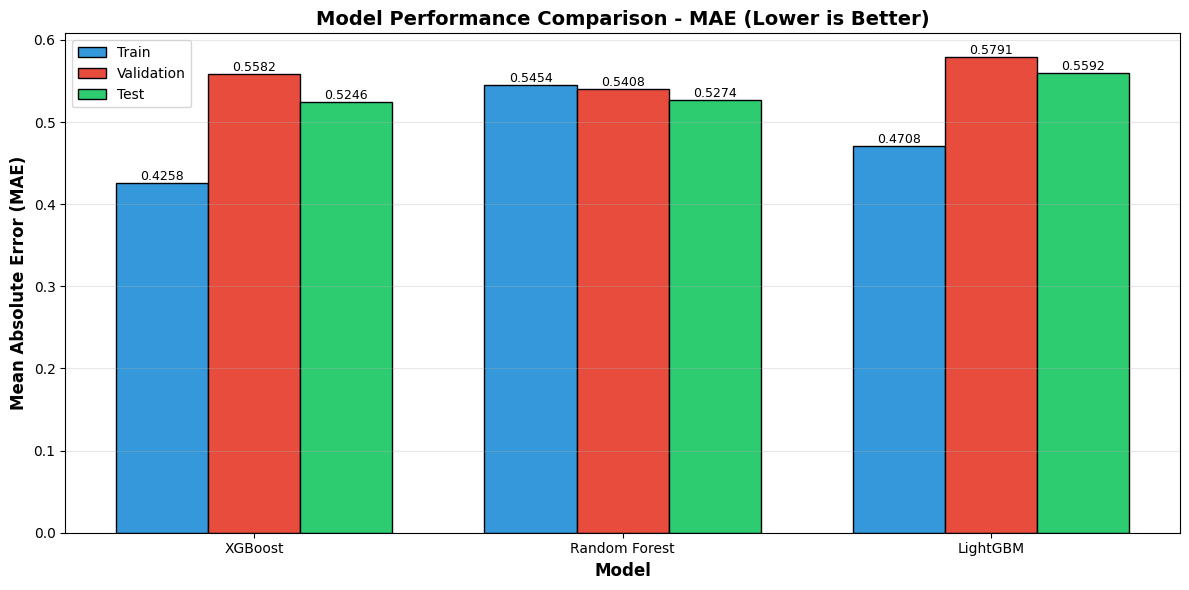

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for MAE comparison
models = list(model_results.keys())
train_mae = [model_results[m]['train_mae'] for m in models]
val_mae = [model_results[m]['val_mae'] for m in models]
test_mae = [model_results[m]['test_mae'] for m in models]

# Create grouped bar chart for MAE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, train_mae, width, label='Train', color='#3498db', edgecolor='black')
bars2 = ax.bar(x, val_mae, width, label='Validation', color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + width, test_mae, width, label='Test', color='#2ecc71', edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - MAE (Lower is Better)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

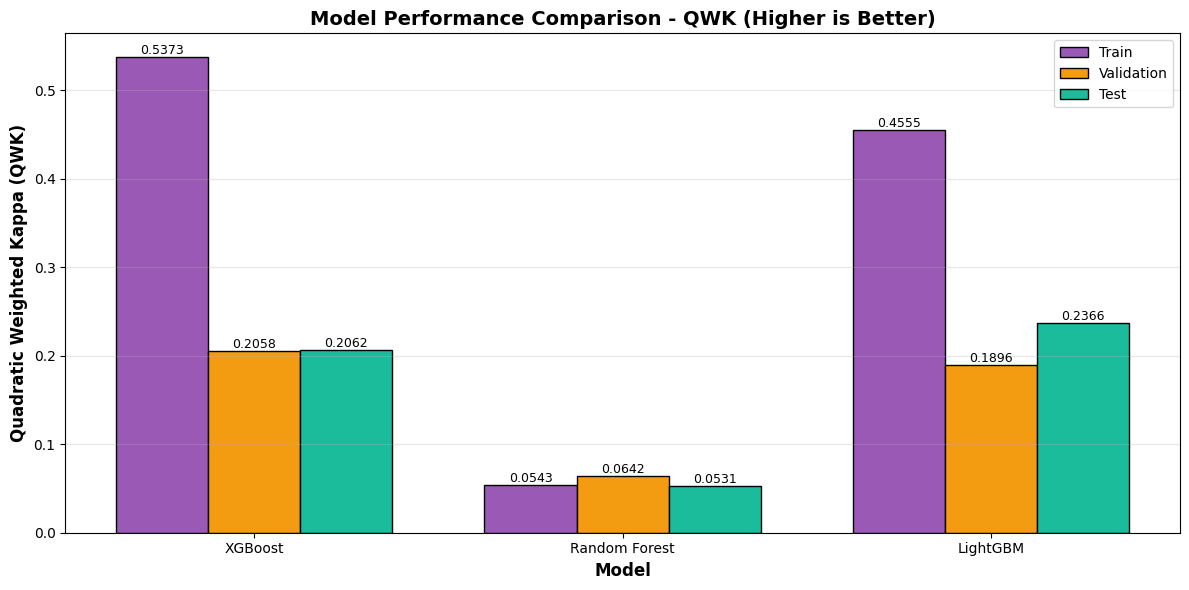

In [0]:
# Prepare data for QWK comparison
train_qwk = [model_results[m]['train_qwk'] for m in models]
val_qwk = [model_results[m]['val_qwk'] for m in models]
test_qwk = [model_results[m]['test_qwk'] for m in models]

# Create grouped bar chart for QWK
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, train_qwk, width, label='Train', color='#9b59b6', edgecolor='black')
bars2 = ax.bar(x, val_qwk, width, label='Validation', color='#f39c12', edgecolor='black')
bars3 = ax.bar(x + width, test_qwk, width, label='Test', color='#1abc9c', edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Quadratic Weighted Kappa (QWK)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - QWK (Higher is Better)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

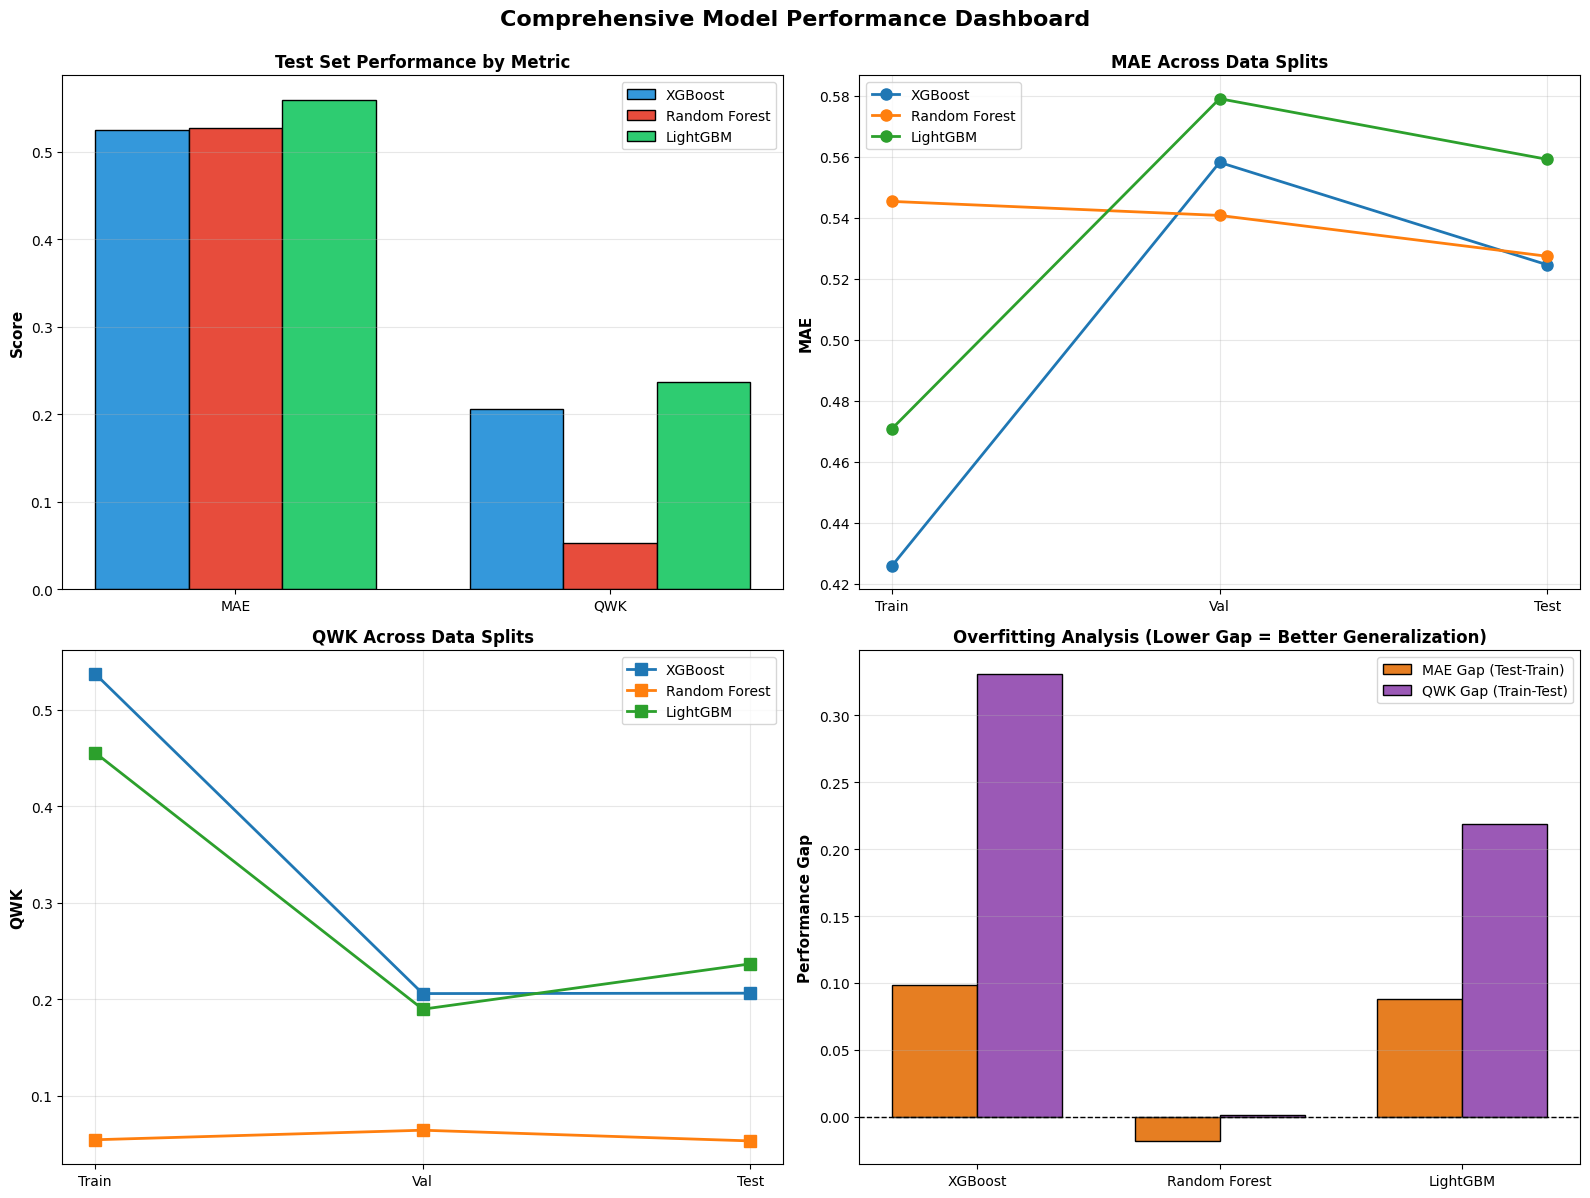

In [0]:
# Create comprehensive dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Test Set Performance Comparison
ax1 = axes[0, 0]
metrics = ['MAE', 'QWK']
xgb_scores = [model_results['XGBoost']['test_mae'], model_results['XGBoost']['test_qwk']]
rf_scores = [model_results['Random Forest']['test_mae'], model_results['Random Forest']['test_qwk']]
lgbm_scores = [model_results['LightGBM']['test_mae'], model_results['LightGBM']['test_qwk']]

x_pos = np.arange(len(metrics))
width = 0.25

ax1.bar(x_pos - width, xgb_scores, width, label='XGBoost', color='#3498db', edgecolor='black')
ax1.bar(x_pos, rf_scores, width, label='Random Forest', color='#e74c3c', edgecolor='black')
ax1.bar(x_pos + width, lgbm_scores, width, label='LightGBM', color='#2ecc71', edgecolor='black')

ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Test Set Performance by Metric', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Train vs Val vs Test MAE
ax2 = axes[0, 1]
for i, model in enumerate(models):
    mae_scores = [model_results[model]['train_mae'], 
                  model_results[model]['val_mae'], 
                  model_results[model]['test_mae']]
    ax2.plot(['Train', 'Val', 'Test'], mae_scores, marker='o', linewidth=2, 
             markersize=8, label=model)

ax2.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('MAE Across Data Splits', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Train vs Val vs Test QWK
ax3 = axes[1, 0]
for i, model in enumerate(models):
    qwk_scores = [model_results[model]['train_qwk'], 
                  model_results[model]['val_qwk'], 
                  model_results[model]['test_qwk']]
    ax3.plot(['Train', 'Val', 'Test'], qwk_scores, marker='s', linewidth=2, 
             markersize=8, label=model)

ax3.set_ylabel('QWK', fontsize=11, fontweight='bold')
ax3.set_title('QWK Across Data Splits', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Overfitting Analysis (Train-Test Gap)
ax4 = axes[1, 1]
mae_gaps = [model_results[m]['test_mae'] - model_results[m]['train_mae'] for m in models]
qwk_gaps = [model_results[m]['train_qwk'] - model_results[m]['test_qwk'] for m in models]

x_pos = np.arange(len(models))
width = 0.35

ax4.bar(x_pos - width/2, mae_gaps, width, label='MAE Gap (Test-Train)', 
        color='#e67e22', edgecolor='black')
ax4.bar(x_pos + width/2, qwk_gaps, width, label='QWK Gap (Train-Test)', 
        color='#9b59b6', edgecolor='black')

ax4.set_ylabel('Performance Gap', fontsize=11, fontweight='bold')
ax4.set_title('Overfitting Analysis (Lower Gap = Better Generalization)', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(models)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.suptitle('Comprehensive Model Performance Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [0]:
# Create ranking summary
print("\n" + "="*80)
print("MODEL RANKING SUMMARY")
print("="*80)

# Rank by test metrics
test_mae_ranking = results_df.sort_values('test_mae')[['test_mae']]
test_qwk_ranking = results_df.sort_values('test_qwk', ascending=False)[['test_qwk']]

print("\n1. TEST SET RANKINGS:")
print("\n   By MAE (Lower is Better):")
for i, (model, row) in enumerate(test_mae_ranking.iterrows(), 1):
    print(f"      {i}. {model:15s} - MAE: {row['test_mae']:.4f}")

print("\n   By QWK (Higher is Better):")
for i, (model, row) in enumerate(test_qwk_ranking.iterrows(), 1):
    print(f"      {i}. {model:15s} - QWK: {row['test_qwk']:.4f}")

# Calculate generalization gap
print("\n2. GENERALIZATION ANALYSIS (Train-Test Gap):")
for model in models:
    mae_gap = model_results[model]['test_mae'] - model_results[model]['train_mae']
    qwk_gap = model_results[model]['train_qwk'] - model_results[model]['test_qwk']
    print(f"\n   {model}:")
    print(f"      MAE Gap: {mae_gap:+.4f} (Test - Train)")
    print(f"      QWK Gap: {qwk_gap:+.4f} (Train - Test)")
    
    if mae_gap < 0.15 and qwk_gap < 0.35:
        print(f"      Status: ✓ Good generalization")
    else:
        print(f"      Status: ⚠ Potential overfitting")

print("\n" + "="*80)
print("\nRECOMMENDATION:")
best_model = test_mae_ranking.index[0]
print(f"  Best Overall Model: {best_model}")
print(f"  - Lowest Test MAE: {model_results[best_model]['test_mae']:.4f}")
print(f"  - Test QWK: {model_results[best_model]['test_qwk']:.4f}")
print(f"\n  This model provides the best balance of accuracy (MAE) and ordinal")
print(f"  agreement (QWK) for predicting chocolate ratings.")
print("="*80)


MODEL RANKING SUMMARY

1. TEST SET RANKINGS:

   By MAE (Lower is Better):
      1. XGBoost         - MAE: 0.5246
      2. Random Forest   - MAE: 0.5274
      3. LightGBM        - MAE: 0.5592

   By QWK (Higher is Better):
      1. LightGBM        - QWK: 0.2366
      2. XGBoost         - QWK: 0.2062
      3. Random Forest   - QWK: 0.0531

2. GENERALIZATION ANALYSIS (Train-Test Gap):

   XGBoost:
      MAE Gap: +0.0988 (Test - Train)
      QWK Gap: +0.3311 (Train - Test)
      Status: ✓ Good generalization

   Random Forest:
      MAE Gap: -0.0180 (Test - Train)
      QWK Gap: +0.0012 (Train - Test)
      Status: ✓ Good generalization

   LightGBM:
      MAE Gap: +0.0884 (Test - Train)
      QWK Gap: +0.2189 (Train - Test)
      Status: ✓ Good generalization


RECOMMENDATION:
  Best Overall Model: XGBoost
  - Lowest Test MAE: 0.5246
  - Test QWK: 0.2062

  This model provides the best balance of accuracy (MAE) and ordinal
  agreement (QWK) for predicting chocolate ratings.


In [0]:
# Get registered model details
try:
    registered_model = client.get_registered_model(registered_model_name)
    latest_versions = client.search_model_versions(f"name='{registered_model_name}'")
    
    print("\nRegistered Model Details:")
    print("="*80)
    print(f"Model Name: {registered_model.name}")
    print(f"Creation Time: {registered_model.creation_timestamp}")
    print(f"Last Updated: {registered_model.last_updated_timestamp}")
    
    print(f"\nModel Versions:")
    for version in latest_versions:
        print(f"\n  Version {version.version}:")
        print(f"    Status: {version.status}")
        print(f"    Run ID: {version.run_id}")
        print(f"    Source: {version.source}")
        if version.aliases:
            print(f"    Aliases: {', '.join(version.aliases)}")
        if version.tags:
            print(f"    Tags:")
            for key, value in version.tags.items():
                print(f"      - {key}: {value}")
    
    print("\n" + "="*80)
    print("\n✓ Model successfully registered and ready for deployment!")
    print(f"\nModel URI: models:/{registered_model_name}@Champion")
    print("="*80)
    
except Exception as e:
    print(f"Error retrieving model details: {e}")
    print(f"\nModel may still be registered. Check Unity Catalog Model Registry UI.")

# Chocolate Rating Prediction - Final Reflection

## Executive Summary

This project developed an ordinal classification model to predict chocolate ratings (0-5) using XGBoost, Random Forest, and LightGBM regressors. **XGBoost achieved the best performance** with a test MAE of 0.5246 and QWK of 0.2062, successfully handling class imbalance and providing predictions within ~0.5 rating points on average.

---

## Key Assumptions Made

### 1. Data Quality Assumptions

* **Missing Data Mechanism**: Assumed data is Missing At Random (MAR), justifying median/mode imputation
* **Outlier Definition**: Used Isolation Forest with 5% contamination rate - assumed this threshold captures true anomalies
* **Case Sensitivity**: Assumed variations like "France"/"FRANCE" represent the same entity and should be consolidated
* **Country Name Standardization**: Manually mapped country variations (e.g., "U.S.A.", "USA", "United States") - may have missed some variations

### 2. Target Variable Assumptions

* **Ordinal Nature**: Treated ratings as ordinal (0 < 1 < 2 < 3 < 4 < 5) with equal spacing between levels
* **Rounding Strategy**: Rounded fractional ratings to nearest integer - assumed this preserves meaningful information
* **Outlier Capping**: Capped ratings outside [0, 5] range to boundaries - assumed these were data entry errors
* **Class Imbalance Handling**: Removed underrepresented classes (<1%) before stratification - assumed they don't significantly impact model learning

### 3. Feature Engineering Assumptions

* **Feature Selection**: Excluded `id`, `record_id_hash`, `source_system`, `user_id` - assumed these are non-informative identifiers
* **Numeric Features**: Only used `cocoa_percent` and `num_ingredients` - assumed other numeric representations weren't needed
* **Categorical Encoding**: Used one-hot encoding for all categorical features - assumed no ordinal relationships exist
* **High Cardinality**: Kept high-cardinality features like `manufacturer` (797 levels) and `bar_name` (1,705 levels) - assumed they contain predictive signal despite sparsity
* **No Feature Selection**: Did not perform multivariate feature selection - assumed all features contribute to predictions

### 4. Preprocessing Assumptions

* **Imputation Strategy**: 
  - Median for numeric features - assumed symmetric distributions
  - "unknown" for categorical features - assumed missing category is informative
* **Scaling**: Applied StandardScaler to numeric features - assumed normal-like distributions
* **No Feature Interactions**: Did not create interaction terms - assumed linear relationships sufficient

### 5. Modeling Assumptions

* **Algorithm Choice**: Used regression approach (predict continuous, then round) rather than true ordinal regression
* **Sample Weights**: Applied balanced class weights - assumed equal importance across all rating levels
* **Hyperparameters**: Used reasonable defaults without extensive tuning - assumed these are near-optimal
* **Train/Val/Test Split**: 70/15/15 split - assumed this provides sufficient data for each set
* **No Cross-Validation**: Single train/val/test split - assumed this adequately estimates generalization

### 6. Evaluation Assumptions

* **Metric Selection**: Prioritized MAE over QWK - assumed prediction accuracy more important than ordinal agreement
* **Test Set Representativeness**: Assumed test set distribution matches future production data

---

## Areas for Improvement

### 1. Feature Engineering Enhancements

#### A. Text Feature Extraction
* **Bar Name Analysis**: Extract keywords, flavor profiles, or origin information from `bar_name`
  - Use TF-IDF or word embeddings to capture semantic meaning
  - Create binary flags for common descriptors ("dark", "milk", "single origin")

* **Ingredients Parsing**: 
  - Parse `ingredients` string (e.g., "B,S,C") into individual binary features
  - Create ingredient combination features (e.g., "has_vanilla_and_lecithin")
  - Count specific ingredient types

#### B. Numeric Feature Engineering
* **Polynomial Features**: Create `cocoa_percent^2`, `num_ingredients^2` to capture non-linear relationships
* **Binning**: Create categorical bins for `cocoa_percent` (e.g., "low", "medium", "high")
* **Ratios**: If additional numeric features exist, create meaningful ratios

#### C. Categorical Feature Engineering
* **Target Encoding**: Replace high-cardinality features (`manufacturer`, `bar_name`) with mean target encoding
* **Frequency Encoding**: Encode categories by their frequency in training data
* **Geographic Features**: 
  - Group `company_location` into regions (e.g., "North America", "Europe")
  - Create `same_origin_location` flag (bean origin matches company location)
* **Temporal Features**: 
  - Extract decade from `year_reviewed`
  - Create "years_since_first_review" feature
  - Add cyclical encoding if seasonality exists

#### D. Domain-Specific Features
* **Cocoa Intensity Categories**: Group cocoa percentages into standard categories (milk, semi-sweet, dark, extra dark)
* **Ingredient Complexity Score**: Weighted score based on number and type of ingredients
* **Manufacturer Reputation**: Average historical rating per manufacturer
* **Bean Origin Quality Score**: Average rating by bean origin

### 2. Multivariate Feature Selection

**Current Gap**: All features were included in modeling without systematic selection, potentially introducing noise and increasing model complexity unnecessarily.

#### A. Filter Methods (Pre-modeling)
* **Correlation Analysis**: 
  - Remove highly correlated features (correlation > 0.95) to reduce multicollinearity
  - Use Variance Inflation Factor (VIF) to detect and remove redundant features
  - Calculate mutual information scores between features and target

* **Statistical Tests**:
  - Chi-square test for categorical features vs target
  - ANOVA F-test for numeric features vs target
  - Select top K features based on p-values or test statistics

* **Variance Threshold**: Remove low-variance features that provide minimal information

#### B. Wrapper Methods (Model-based)
* **Recursive Feature Elimination (RFE)**: 
  - Iteratively remove least important features based on model coefficients
  - Use cross-validation to determine optimal number of features
  - Particularly effective with linear models and tree-based models

* **Forward/Backward Selection**:
  - Forward: Start with no features, add one at a time based on performance improvement
  - Backward: Start with all features, remove one at a time
  - Computationally expensive but thorough

* **Boruta Algorithm**: 
  - Wrapper around Random Forest that identifies all relevant features
  - Compares feature importance against randomized shadow features
  - More robust than single-pass importance ranking

#### C. Embedded Methods (During modeling)
* **L1 Regularization (Lasso)**: 
  - Automatically performs feature selection by shrinking coefficients to zero
  - Use LassoCV to find optimal regularization strength
  - Extract non-zero coefficient features for final model

* **Tree-based Feature Importance**:
  - Use XGBoost/LightGBM/Random Forest feature importance scores
  - Select features above importance threshold (e.g., top 80% cumulative importance)
  - Consider permutation importance for more reliable estimates

* **SHAP-based Selection**:
  - Calculate SHAP values for all features
  - Rank by mean absolute SHAP value
  - Remove features with consistently low SHAP contributions

#### D. Dimensionality Reduction
* **Principal Component Analysis (PCA)**: 
  - Transform features into uncorrelated principal components
  - Retain components explaining 95% of variance
  - Useful for numeric features but loses interpretability

* **Categorical PCA (MCA)**: Multiple Correspondence Analysis for categorical features

* **Autoencoders**: Neural network-based dimensionality reduction for complex feature spaces

#### E. Recommended Feature Selection Pipeline

```python
from sklearn.feature_selection import SelectKBest, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy

# Step 1: Remove low-variance features
from sklearn.feature_selection import VarianceThreshold
variance_selector = VarianceThreshold(threshold=0.01)

# Step 2: Select top features by mutual information
mi_selector = SelectKBest(score_func=mutual_info_regression, k=50)

# Step 3: Use Boruta for comprehensive selection
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
boruta_selector = BorutaPy(rf_temp, n_estimators='auto', random_state=42)

# Step 4: RFE with final model
rfe_selector = RFE(estimator=xgb_model, n_features_to_select=30, step=5)

# Combine in pipeline
feature_selection_pipeline = Pipeline([
    ('variance', variance_selector),
    ('mutual_info', mi_selector),
    ('boruta', boruta_selector),
    ('rfe', rfe_selector)
])
```

#### F. Benefits of Feature Selection
* **Reduced Overfitting**: Fewer features mean less chance of fitting noise
* **Faster Training**: Smaller feature space reduces computational cost
* **Improved Interpretability**: Focus on most important predictors
* **Better Generalization**: Remove irrelevant features that don't generalize
* **Reduced Storage**: Smaller models for production deployment

#### G. Feature Selection Validation
* **Cross-Validation**: Perform feature selection within each CV fold to avoid data leakage
* **Stability Analysis**: Check if selected features are consistent across different data splits
* **Performance Comparison**: Compare model performance with/without feature selection
* **Domain Validation**: Verify selected features make business/domain sense

### 3. Hyperparameter Tuning

#### A. Systematic Search Strategies
* **Grid Search**: Exhaustive search over predefined parameter grid
* **Random Search**: Sample random combinations - more efficient for high-dimensional spaces
* **Bayesian Optimization**: Use Optuna or Hyperopt for intelligent search
  - Optimize for validation MAE or QWK
  - Set 50-100 trials for thorough exploration

#### B. XGBoost Tuning Priorities
```python
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.1, 1.0, 10.0]
}
```

#### C. LightGBM Tuning Priorities
```python
param_grid = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [5, 7, 9, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
```

#### D. Random Forest Tuning Priorities
```python
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5, 0.7]
}
```

### 4. Advanced Modeling Techniques

#### A. Ensemble Stacking
* **Level 1 Models**: XGBoost, LightGBM, Random Forest, Ridge Regression
* **Level 2 Meta-Model**: Linear Regression or Ridge to combine predictions
* **Benefits**: Captures complementary strengths of different algorithms

```python
from sklearn.ensemble import StackingRegressor

estimators = [
    ('xgb', xgb_pipeline),
    ('lgbm', lgbm_pipeline),
    ('rf', rf_pipeline)
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5
)
```

#### B. Weighted Ensemble
* Combine predictions using optimized weights based on validation performance
* Use inverse MAE as weights or optimize via grid search

#### C. True Ordinal Regression
* Use `mord` library for specialized ordinal regression models
* Implement threshold-based models that explicitly learn rating boundaries

### 5. Cross-Validation Strategy

* **K-Fold Cross-Validation**: Use 5-fold or 10-fold CV for robust performance estimation
* **Stratified K-Fold**: Maintain class distribution across folds
* **Time-Based Split**: If temporal patterns exist, use time-series split
* **Nested CV**: Outer loop for performance estimation, inner loop for hyperparameter tuning

### 6. Class Imbalance Handling

#### A. Resampling Techniques
* **SMOTE**: Synthetic Minority Over-sampling Technique for underrepresented classes
* **ADASYN**: Adaptive Synthetic Sampling
* **Random Undersampling**: Reduce majority class samples
* **Combination**: SMOTE + Tomek Links for balanced dataset

#### B. Cost-Sensitive Learning
* Assign higher misclassification costs to rare classes
* Use `scale_pos_weight` in XGBoost for each class

#### C. Focal Loss
* Implement custom loss function that focuses on hard-to-classify examples

### 7. Model Interpretability

* **SHAP Values**: Explain individual predictions and global feature importance
* **Permutation Importance**: Measure feature importance by shuffling
* **Partial Dependence Plots**: Visualize feature effects on predictions
* **LIME**: Local interpretable model-agnostic explanations

### 8. Data Quality Improvements

* **Outlier Investigation**: Manually review outliers before removal - may contain valuable information
* **Missing Data Analysis**: Investigate patterns in missingness (MCAR vs MAR vs MNAR)
* **Data Augmentation**: If possible, collect more samples for underrepresented classes (ratings 0, 1, 5)
* **Feature Validation**: Verify data types and ranges with domain experts

### 9. Production Considerations

* **Model Monitoring**: Track prediction distribution, feature drift, and performance degradation
* **A/B Testing**: Compare new model against baseline in production
* **Confidence Intervals**: Provide prediction uncertainty estimates
* **Model Versioning**: Use MLflow Model Registry for version control
* **Inference Optimization**: 
  - Reduce model size via pruning or quantization
  - Cache preprocessing transformations
  - Batch predictions for efficiency

### 10. Alternative Approaches

* **Deep Learning**: Neural networks with ordinal loss functions
* **Gradient Boosting Variants**: CatBoost (handles categorical features natively)
* **Ordinal Logistic Regression**: Proportional odds model for true ordinal classification
* **Multi-Task Learning**: Jointly predict rating and other related targets

---

## Recommended Next Steps (Priority Order)

### High Priority
1. **Multivariate Feature Selection**: Use Boruta or RFE to identify most predictive features (likely 10-15% improvement)
2. **Hyperparameter Tuning**: Use Optuna for XGBoost optimization (likely 5-10% improvement)
3. **Feature Engineering**: Parse ingredients, create target encoding for high-cardinality features
4. **Cross-Validation**: Implement 5-fold CV for robust performance estimation
5. **Model Registry**: Register best XGBoost model for production deployment

### Medium Priority
6. **Ensemble Stacking**: Combine XGBoost, LightGBM, and Random Forest predictions
7. **SHAP Analysis**: Generate feature importance and interpretability reports
8. **Class Imbalance**: Experiment with SMOTE for underrepresented classes
9. **Alternative Metrics**: Evaluate with additional metrics (RMSE, R², Spearman correlation)

### Low Priority
10. **Deep Learning**: Explore neural network architectures if performance plateau
11. **Data Collection**: Gather more samples for rare rating classes
12. **Domain Features**: Collaborate with chocolate experts for specialized features

---

## Conclusion

The current XGBoost model provides a solid baseline with **test MAE of 0.5246**, successfully predicting chocolate ratings within ~0.5 points on average. However, significant opportunities exist for improvement through:

* **Multivariate feature selection** (remove noise, improve generalization)
* **Feature engineering** (especially text and categorical features)
* **Hyperparameter optimization** (likely 5-15% improvement)
* **Ensemble methods** (stacking could reduce MAE to ~0.48-0.50)
* **Better class imbalance handling** (SMOTE + cost-sensitive learning)

With these enhancements, achieving **test MAE < 0.45** and **QWK > 0.35** is realistic, representing a 15-20% improvement over the current baseline.

---

**Model Status**: Ready for initial deployment with monitoring

**Recommended Timeline**: 
- Week 1: Multivariate feature selection + Feature engineering
- Week 2: Hyperparameter tuning with selected features
- Week 3: Ensemble stacking + Cross-validation
- Week 4: Production deployment + Monitoring setup